# Home task: Hierarchical clusterins and DBSCAN

## Import libraries


In [56]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram

## Generate sample data

In [57]:
# Create sample data
X, y = make_blobs(
    n_samples=500,
    n_features=2,
    centers=5,
    cluster_std=0.6,
    random_state=0
)

# Colors for true labels
colors = np.array([plt.cm.Spectral(val) for val in np.linspace(0, 1, len(set(y)))])

## Visualize the original dataset


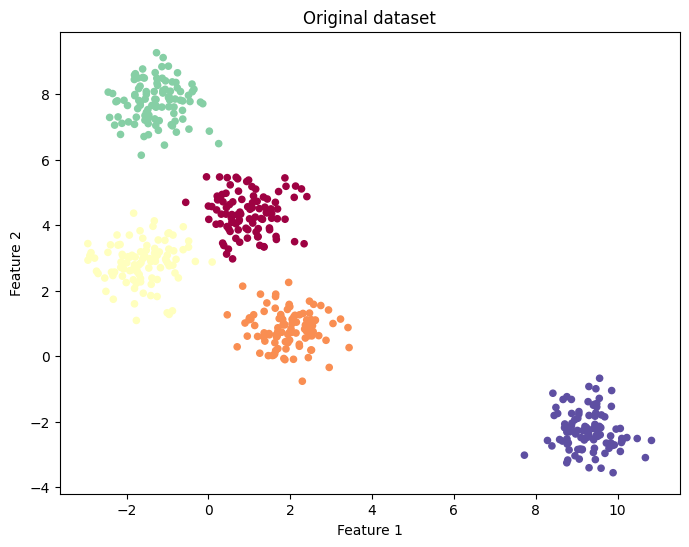

In [58]:
# Plot original data with true labels
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=colors[y], s=20)
plt.title("Original dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Agglomerative clustering with complete linkage

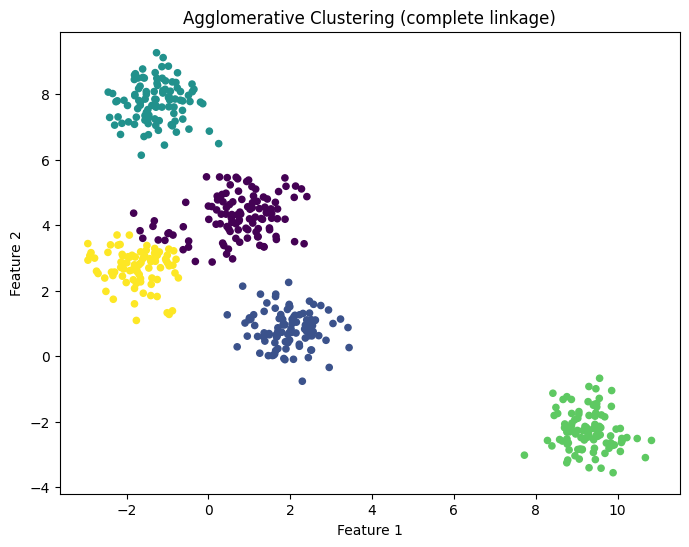

In [59]:
# Agglomerative clustering with complete linkage
agg_complete = AgglomerativeClustering(n_clusters=5, linkage='complete')
labels_complete = agg_complete.fit_predict(X)

# Plot clustering result
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_complete, s=20, cmap='viridis')
plt.title("Agglomerative Clustering (complete linkage)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Agglomerative clustering with single linkage


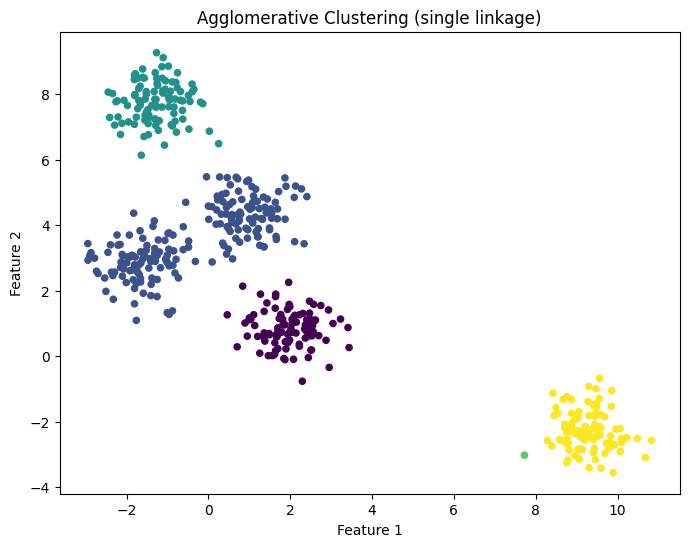

In [60]:
# Agglomerative clustering with single linkage
agg_single = AgglomerativeClustering(n_clusters=5, linkage='single')
labels_single = agg_single.fit_predict(X)

# Plot clustering result
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_single, s=20, cmap='viridis')
plt.title("Agglomerative Clustering (single linkage)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Dendrogram (hierarchical clustering)

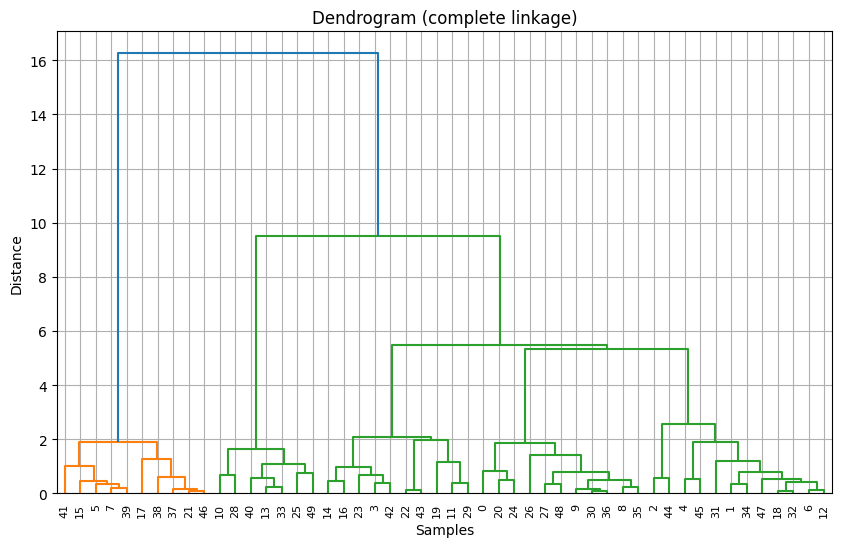

In [ ]:
# use smaller subset for better visualization
X_small = X[:50]

# build dendrogram for complete linkage
linked_complete = linkage(X_small, method='complete')

plt.figure(figsize=(10, 6))
dendrogram(linked_complete)
plt.title("Dendrogram (complete linkage)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

## Dendrogram (single linkage)


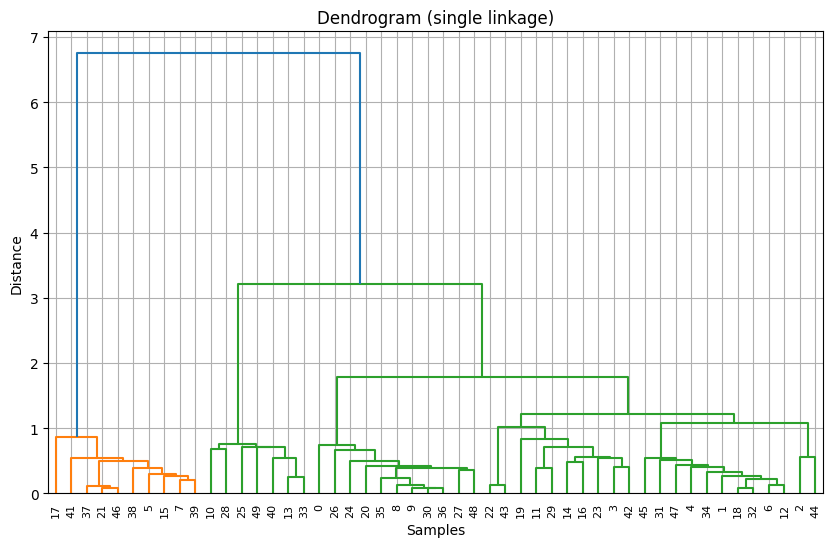

In [ ]:
# build dendrogram for single linkage
linked_single = linkage(X_small, method='single')

plt.figure(figsize=(10, 6))
dendrogram(linked_single)
plt.title("Dendrogram (single linkage)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

## Data scaling for DBSCAN


In [97]:
# scale data for DBSCAN
X_scaled = StandardScaler().fit_transform(X)

## k-distance graph

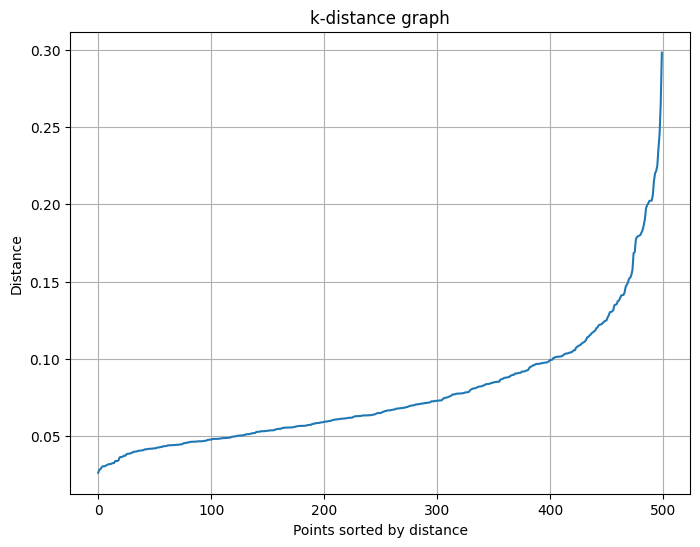

In [98]:
k = 5

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, k-1])

plt.figure(figsize=(8,6))
plt.plot(distances)
plt.title("k-distance graph")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

## DBSCAN clustering


In [104]:
# apply DBSCAN on scaled data
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

# show unique labels
print("DBSCAN labels:", np.unique(labels_dbscan))

DBSCAN labels: [0 1]


## Visualize DBSCAN result


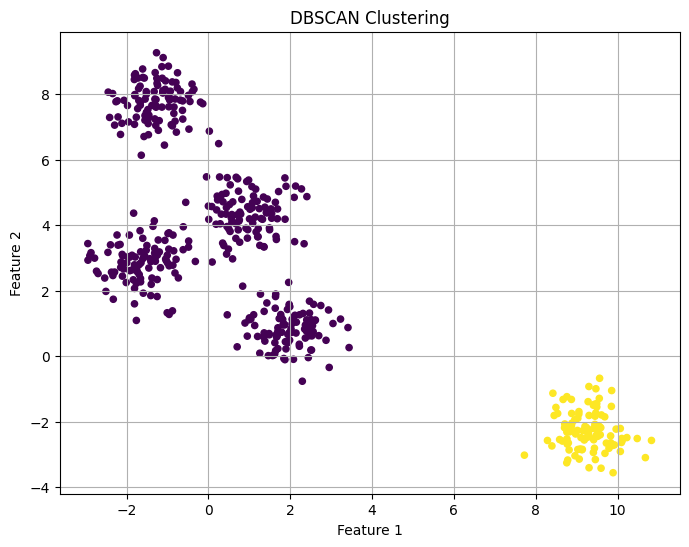

In [109]:
# plot DBSCAN result
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_dbscan, s=20, cmap='viridis')
plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

## Elbow method for KMeans


In [110]:
# Find inertia for different k values
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

## Plot the elbow curve


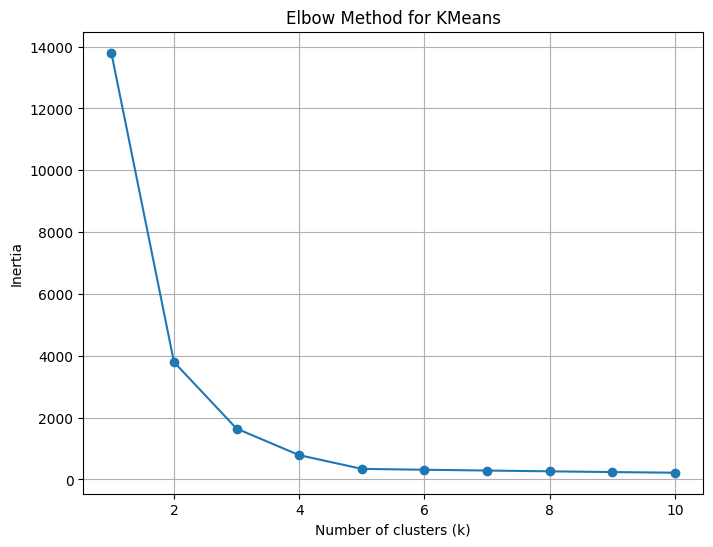

In [111]:
# Plot elbow method
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia, marker='o')
plt.title("Elbow Method for KMeans")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

## Apply KMeans with the best k


In [112]:
# Apply KMeans with chosen k
kmeans = KMeans(n_clusters=5, random_state=0, n_init=10)
labels_kmeans = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

## Visualize KMeans result


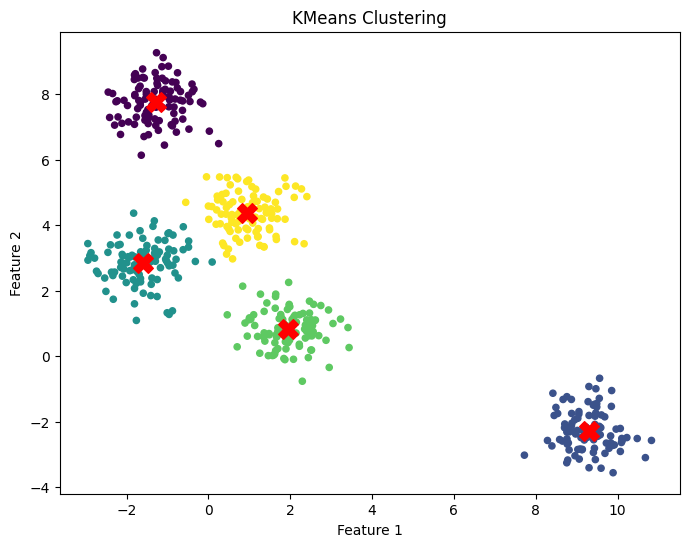

In [113]:
# Plot KMeans result
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_kmeans, s=20, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], s=200, marker='X', c='red')
plt.title("KMeans Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()